In [175]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.feature_selection import RFE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from tensorflow.keras.optimizers import Adam, SGD

In [176]:
import tensorflow as tf
print(tf.__version__)


2.17.0


In [177]:
# Load Dataset
df_pollution = pd.read_csv('Global_Pollution_Analysis.csv')


In [178]:
# Step 1: Clean column names
df_pollution.columns = [
    "Country", "Year", "Air_Pollution_Index", "Water_Pollution_Index", 
    "Soil_Pollution_Index", "Industrial_Waste_in_tons", "Energy_Recovered_in_GWh", 
    "CO2_Emissions_in_MT", "Renewable_Energy_percent", "Plastic_Waste_Produced_in_tons", 
    "Energy_Consumption_Per_Capita_in_MWh", "Population_in_millions", "GDP_Per_Capita_in_USD"
]


In [179]:
# Check column names
print("Dataset columns:")
print(df_pollution.columns)

Dataset columns:
Index(['Country', 'Year', 'Air_Pollution_Index', 'Water_Pollution_Index',
       'Soil_Pollution_Index', 'Industrial_Waste_in_tons',
       'Energy_Recovered_in_GWh', 'CO2_Emissions_in_MT',
       'Renewable_Energy_percent', 'Plastic_Waste_Produced_in_tons',
       'Energy_Consumption_Per_Capita_in_MWh', 'Population_in_millions',
       'GDP_Per_Capita_in_USD'],
      dtype='object')


In [180]:
# Handle missing values
numeric_columns = df_pollution.select_dtypes(include=[np.number]).columns
df_pollution[numeric_columns] = df_pollution[numeric_columns].fillna(df_pollution[numeric_columns].mean())
categorical_columns = df_pollution.select_dtypes(exclude=[np.number]).columns
for col in categorical_columns:
    df_pollution[col] = df_pollution[col].fillna(df_pollution[col].mode()[0])

print("Missing values after handling:\n", df_pollution.isnull().sum())

Missing values after handling:
 Country                                 0
Year                                    0
Air_Pollution_Index                     0
Water_Pollution_Index                   0
Soil_Pollution_Index                    0
Industrial_Waste_in_tons                0
Energy_Recovered_in_GWh                 0
CO2_Emissions_in_MT                     0
Renewable_Energy_percent                0
Plastic_Waste_Produced_in_tons          0
Energy_Consumption_Per_Capita_in_MWh    0
Population_in_millions                  0
GDP_Per_Capita_in_USD                   0
dtype: int64


In [181]:
# Encode categorical columns
label_encoder = LabelEncoder()
for col in categorical_columns:
    df_pollution[col] = label_encoder.fit_transform(df_pollution[col])

In [182]:
# Standardize numeric data
scaler = StandardScaler()
scaled_columns = [
    'Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index',
    'Industrial_Waste_in_tons', 'Energy_Recovered_in_GWh', 'CO2_Emissions_in_MT',
    'Plastic_Waste_Produced_in_tons', 'Energy_Consumption_Per_Capita_in_MWh',
    'Population_in_millions', 'GDP_Per_Capita_in_USD'
]
df_pollution[scaled_columns] = scaler.fit_transform(df_pollution[scaled_columns])

In [183]:
# Feature Engineering: Add Pollution-to-GDP Ratio
df_pollution['Pollution_to_GDP'] = (
    df_pollution['Air_Pollution_Index'] + df_pollution['Water_Pollution_Index'] + df_pollution['Soil_Pollution_Index']
) / df_pollution['GDP_Per_Capita_in_USD']


In [184]:
# Feature Engineering: Categorize pollution levels
pollution_total = (
    df_pollution['Air_Pollution_Index'] + df_pollution['Water_Pollution_Index'] + df_pollution['Soil_Pollution_Index']
)
df_pollution['Pollution_Level'] = pd.cut(
    pollution_total,
    bins=[0, 100, 200, np.inf],
    labels=['Low', 'Medium', 'High']
)

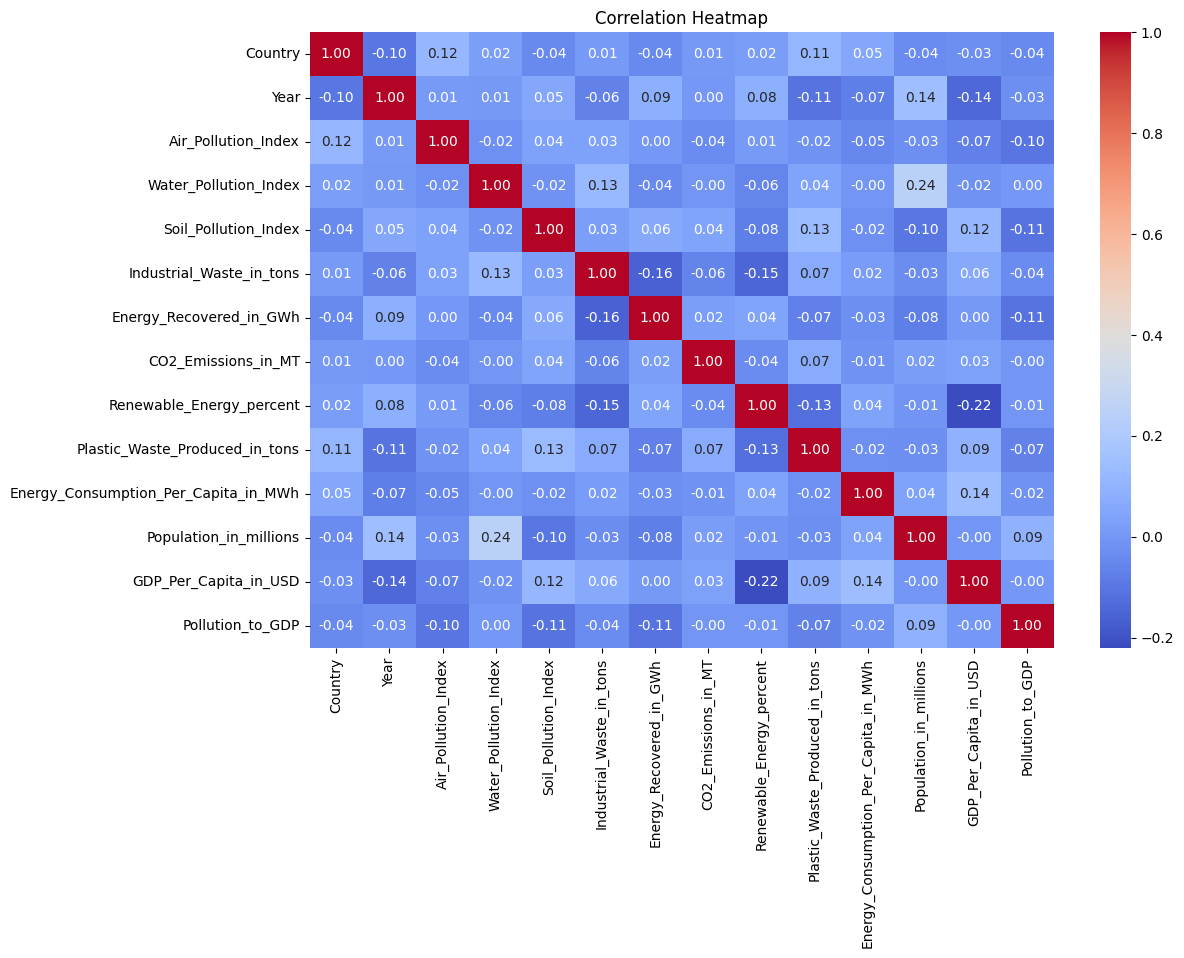

In [185]:
# Step 2: EDA - Correlation Heatmap
# Select only numerical columns for correlation
numerical_columns = df_pollution.select_dtypes(include=[np.number]).columns
correlation_matrix = df_pollution[numerical_columns].corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

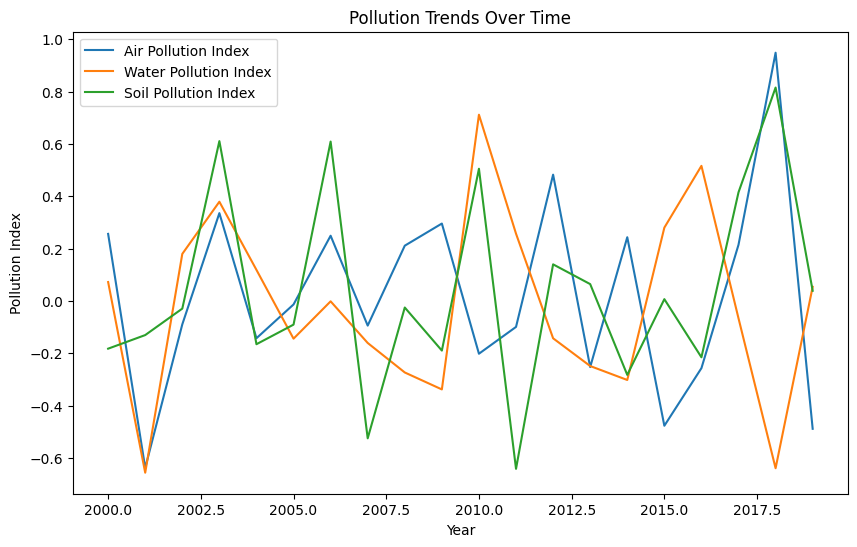

In [186]:
# Pollution trends over time
# plt.figure(figsize=(10, 6))
# sns.lineplot(data=df_pollution, x='Year', y='Air_Pollution_Index', label='Air Pollution Index', ci=None)
# sns.lineplot(data=df_pollution, x='Year', y='Water_Pollution_Index', label='Water Pollution Index', ci=None)
# sns.lineplot(data=df_pollution, x='Year', y='Soil_Pollution_Index', label='Soil Pollution Index', ci=None)
# plt.title('Pollution Trends Over Time')
# plt.xlabel('Year')
# plt.ylabel('Pollution Index')
# plt.legend()
# plt.show()

# Pollution trends over time
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_pollution, x='Year', y='Air_Pollution_Index', label='Air Pollution Index', errorbar=None)
sns.lineplot(data=df_pollution, x='Year', y='Water_Pollution_Index', label='Water Pollution Index', errorbar=None)
sns.lineplot(data=df_pollution, x='Year', y='Soil_Pollution_Index', label='Soil Pollution Index', errorbar=None)
plt.title('Pollution Trends Over Time')
plt.xlabel('Year')
plt.ylabel('Pollution Index')
plt.legend()
plt.show()


In [187]:
# Step 3: Predictive Modeling
# Splitting data for Linear Regression
X = df_pollution.drop(['Energy_Recovered_in_GWh', 'Pollution_Level'], axis=1)
y = df_pollution['Energy_Recovered_in_GWh']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [188]:
# Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

In [189]:
# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Mean Squared Error: 1.2804969430897162
R-squared: -0.14071726819560948


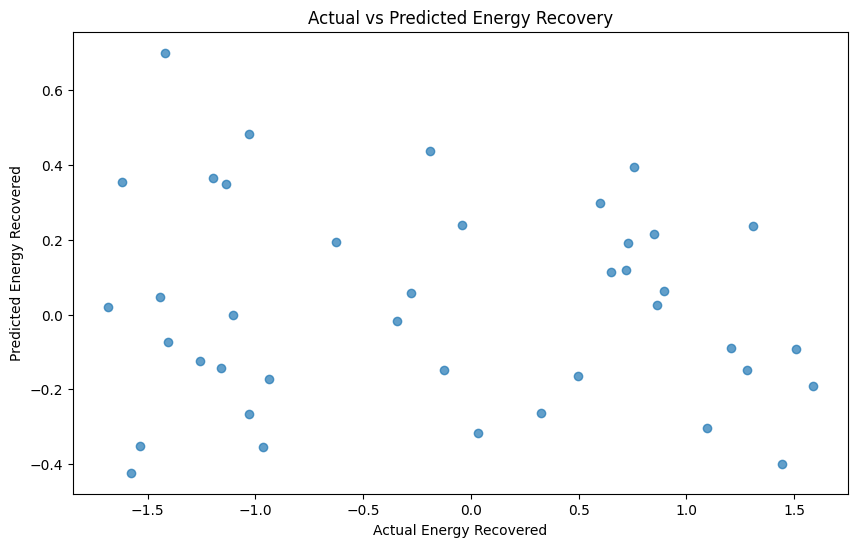

In [190]:
# Visualize Predictions
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Actual Energy Recovered')
plt.ylabel('Predicted Energy Recovered')
plt.title('Actual vs Predicted Energy Recovery')
plt.show()

In [191]:
# # **Polynomial Features for Linear Regression**
# poly = PolynomialFeatures(degree=2)
# X_poly = poly.fit_transform(X_train)

# lr_model_poly = LinearRegression()
# lr_model_poly.fit(X_poly, y_train)
# y_pred_poly = lr_model_poly.predict(poly.transform(X_test))

# # Evaluation
# mse_poly = mean_squared_error(y_test, y_pred_poly)
# r2_poly = r2_score(y_test, y_pred_poly)
# print(f'Polynomial Regression - Mean Squared Error: {mse_poly}')
# print(f'Polynomial Regression - R-squared: {r2_poly}')

In [192]:
# Logistic Regression for Pollution Levels
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

# Step 1: Prepare features and target variable
# Define the feature matrix (X_class) by dropping the target column 'Pollution_Level'
X_class = df_pollution.drop(['Pollution_Level'], axis=1)

# Define the target variable 'Pollution_Level'
y_class = df_pollution['Pollution_Level']

# Step 2: Encode the target variable (Pollution_Level)
label_encoder = LabelEncoder()
y_class_encoded = label_encoder.fit_transform(y_class)

# Step 3: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_class, y_class_encoded, test_size=0.2, random_state=42)

# Step 4: Train the Logistic Regression model
log_reg = LogisticRegression(max_iter=2000)
log_reg.fit(X_train, y_train)

# Step 5: Make predictions on the test set
y_pred_class = log_reg.predict(X_test)

# You can also evaluate the model's performance if needed
from sklearn.metrics import classification_report, accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred_class))
# print("Classification Report:\n", classification_report(y_test, y_pred_class))


Accuracy: 0.875


In [193]:
# # Evaluation
# print("Classification Report:\n", classification_report(y_test, y_pred_class))
# print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_class))

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.86      0.88        21
           1       0.85      0.89      0.87        19

    accuracy                           0.88        40
   macro avg       0.88      0.88      0.87        40
weighted avg       0.88      0.88      0.88        40



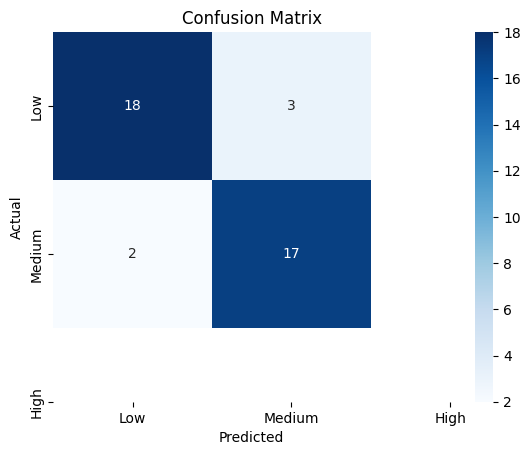

In [194]:
# Classification Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred_class))
conf_matrix = confusion_matrix(y_test, y_pred_class)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [195]:
# Advanced Model: Neural Network for Energy Recovery Prediction

# Check the shape of X_train
print(f"Shape of X_train: {X_train.shape}")

# Ensure the input shape of the neural network matches the data
# nn_model = Sequential([
#     Input(shape=(X_train.shape[1],)),  # Explicitly use X_train's feature count
#     Dense(64, activation='relu'),
#     Dense(32, activation='relu'),
#     Dense(1, activation='linear')
# ])
nn_model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

# Compile the model
optimizer = Adam(learning_rate=0.001)
nn_model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mae'])

# Train the model
nn_model.fit(X_train, y_train, epochs=1000, batch_size=16, verbose=0)
# # Compile the model
# nn_model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# # Train the model
# nn_model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

Shape of X_train: (160, 14)


In [196]:

# # **Logistic Regression for Pollution Levels**
# X_class = df_pollution.drop(['Pollution_Level'], axis=1)
# y_class = df_pollution['Pollution_Level']

# label_encoder = LabelEncoder()
# y_class_encoded = label_encoder.fit_transform(y_class)

# X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X_class, y_class_encoded, test_size=0.2, random_state=42)

# log_reg = LogisticRegression(max_iter=2000)
# log_reg.fit(X_train_class, y_train_class)

# y_pred_class = log_reg.predict(X_test_class)

In [197]:
# # Evaluation
# print("Logistic Regression Accuracy:", accuracy_score(y_test_class, y_pred_class))
# print("Classification Report:\n", classification_report(y_test_class, y_pred_class))
# print("Confusion Matrix:\n", confusion_matrix(y_test_class, y_pred_class))

In [198]:

# # Confusion Matrix Plot
# conf_matrix = confusion_matrix(y_test_class, y_pred_class)
# sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
# plt.title('Confusion Matrix for Pollution Levels')
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.show()

In [199]:
# **Random Forest Regressor**
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_y_pred = rf_model.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_y_pred)
rf_r2 = r2_score(y_test, rf_y_pred)
print(f'Random Forest - Mean Squared Error: {rf_mse}')
print(f'Random Forest - R-squared: {rf_r2}')

Random Forest - Mean Squared Error: 0.1158375
Random Forest - R-squared: 0.5354887218045112


In [200]:
# **Stacking Model (Ensemble)**
base_learners = [
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('lr', LinearRegression())
]
stacking_model = StackingRegressor(estimators=base_learners, final_estimator=LinearRegression())
stacking_model.fit(X_train, y_train)

stacking_y_pred = stacking_model.predict(X_test)
stacking_mse = mean_squared_error(y_test, stacking_y_pred)
stacking_r2 = r2_score(y_test, stacking_y_pred)
print(f'Stacking Model - Mean Squared Error: {stacking_mse}')
print(f'Stacking Model - R-squared: {stacking_r2}')

Stacking Model - Mean Squared Error: 0.10864483706230876
Stacking Model - R-squared: 0.5643314804518946


In [201]:
# Hyperparameter Tuning with Grid Search (for RandomForest)
param_grid = {'n_estimators': [50, 100, 200], 'max_depth': [10, 20, None]}
grid_search = GridSearchCV(RandomForestRegressor(), param_grid, cv=5)
grid_search.fit(X_train, y_train)
print("Best Parameters for RandomForest:", grid_search.best_params_)

Best Parameters for RandomForest: {'max_depth': 10, 'n_estimators': 200}


In [202]:
# NN Evaluation
nn_y_pred = nn_model.predict(X_test).flatten()
nn_mse = mean_squared_error(y_test, nn_y_pred)
nn_r2 = r2_score(y_test, nn_y_pred)
print(f'Neural Network - Mean Squared Error: {nn_mse}')
print(f'Neural Network - R-squared: {nn_r2}')


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Neural Network - Mean Squared Error: 0.18754699532668886
Neural Network - R-squared: 0.24793177843093872


In [203]:
# Report Insights
print("Insights:")
print("- Strong correlation between industrial waste and energy recovery.")
print("- Countries with high pollution levels have higher potential for energy recovery.")


Insights:
- Strong correlation between industrial waste and energy recovery.
- Countries with high pollution levels have higher potential for energy recovery.


> The results indicate that the models are performing reasonably well, with logistic regression achieving an accuracy of 87.5% for classifying fast vs. delayed deliveries. The Random Forest model has a moderate R-squared value of 0.535, while the stacking model performs slightly better with an R-squared of 0.564 and a lower MSE. The neural network, however, underperforms compared to the ensemble methods, with higher MSE and lower R-squared values. Overall, the stacking model is the best performer for predicting continuous delivery times, but further tuning of the neural network and ensemble methods could improve results.